# Где дешевле жить? Предсказание цен в Airbnb - учимся генерировать признаки и интерпретировать результаты модели

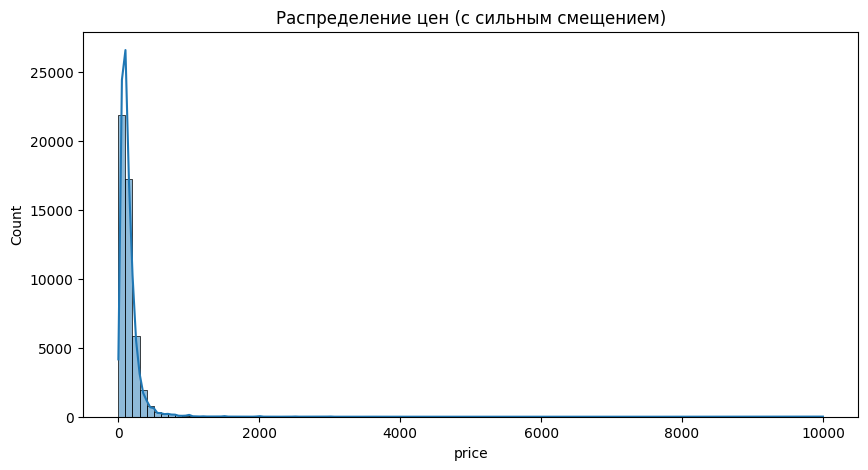

In [ ]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Загрузка данных
df = pd.read_csv('AB_NYC_2019.csv')
print(f'Размер датасета: {df.shape}')
display(df.head())

# Базовая проверка пропусков
display(df.isna().sum().sort_values(ascending=False).head(10))

# Обрезаем экстремальные цены только для визуализаций, чтобы графики были читаемыми
viz_df = df[df['price'] <= df['price'].quantile(0.99)].copy()

# Гистограмма цены
plt.figure(figsize=(10, 5))
sns.histplot(viz_df['price'], bins=80, kde=True)
plt.title('Распределение цены (до 99-го перцентиля)')
plt.xlabel('Цена за ночь')
plt.ylabel('Количество объявлений')
plt.show()

# Scatterplot: география объявлений
sample_df = viz_df.sample(min(10000, len(viz_df)), random_state=42)
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=sample_df, x='longitude', y='latitude', hue='price',
    palette='viridis', alpha=0.45, s=20, edgecolor=None
 )
plt.title('География объявлений: координаты и цена')
plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.legend(title='Цена', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Scatterplot: связь отзывов и цены
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=sample_df, x='number_of_reviews', y='price',
    alpha=0.35, s=18
 )
plt.title('Цена vs количество отзывов')
plt.xlabel('Количество отзывов')
plt.ylabel('Цена за ночь')
plt.show()

# Boxplot: цена по типу комнаты
plt.figure(figsize=(9, 5))
sns.boxplot(data=viz_df, x='room_type', y='price')
plt.title('Распределение цены по типу комнаты')
plt.xlabel('Тип комнаты')
plt.ylabel('Цена за ночь')
plt.ylim(0, viz_df['price'].quantile(0.95))
plt.show()

# Boxplot: цена по району
plt.figure(figsize=(9, 5))
sns.boxplot(data=viz_df, x='neighbourhood_group', y='price')
plt.title('Распределение цены по району')
plt.xlabel('Район')
plt.ylabel('Цена за ночь')
plt.ylim(0, viz_df['price'].quantile(0.95))
plt.show()

In [ ]:
# 2. Предобработка данных для обучения модели
df_model = df.copy()

# Удаляем признаки-идентификаторы и текстовые поля, которые не используем в базовой модели
drop_cols = ['id', 'name', 'host_id', 'host_name', 'last_review']
df_model = df_model.drop(columns=drop_cols)

# Обрабатываем пропуски
df_model['reviews_per_month'] = df_model['reviews_per_month'].fillna(0)

# Удаляем некорректные и экстремальные цены
low_q = df_model['price'].quantile(0.01)
high_q = df_model['price'].quantile(0.99)
df_model = df_model[(df_model['price'] >= low_q) & (df_model['price'] <= high_q)].copy()

# Генерируем гео-признак: дистанция до Times Square
manhattan_lat, manhattan_lon = 40.7580, -73.9855
df_model['dist_to_center'] = np.sqrt(
    (df_model['latitude'] - manhattan_lat) ** 2 + (df_model['longitude'] - manhattan_lon) ** 2
)

# Лог-трансформация целевой переменной для более стабильного обучения
df_model['price_log'] = np.log1p(df_model['price'])

# Формируем X/y
X = df_model.drop(columns=['price', 'price_log'])
y = df_model['price_log']

# Явно задаем типы признаков
cat_features = ['neighbourhood_group', 'neighbourhood', 'room_type']
num_features = [
    'latitude', 'longitude', 'minimum_nights', 'number_of_reviews',
    'reviews_per_month', 'calculated_host_listings_count',
    'availability_365', 'dist_to_center'
 ]

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Пайплайны предобработки
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ]
)

print(f'После предобработки размер: {df_model.shape}')
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

               Model        R2        MAE       RMSE
0  Linear Regression  0.570749  48.567461  90.670690
1            RidgeCV  0.571010  48.559594  90.709057
2            LassoCV  0.552533  49.197356  91.939317
3       ElasticNetCV  0.564670  48.732852  91.140391


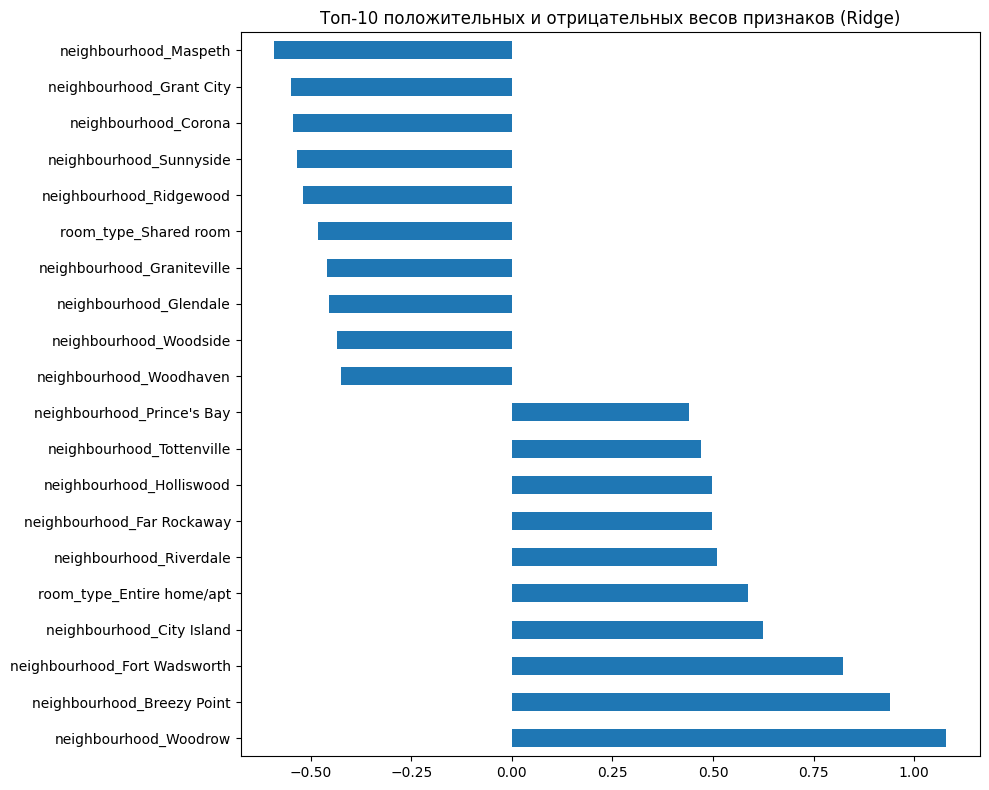

In [ ]:
# 3. Обучение k-NN, оценка качества и настройка гиперпараметров

# Базовая модель k-NN
knn_baseline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', KNeighborsRegressor())
])

knn_baseline.fit(X_train, y_train)
y_pred_log_base = knn_baseline.predict(X_test)

# Метрики считаем в исходной шкале цены
y_test_price = np.expm1(y_test)
y_pred_price_base = np.expm1(y_pred_log_base)

base_r2_log = r2_score(y_test, y_pred_log_base)
base_mae = mean_absolute_error(y_test_price, y_pred_price_base)
base_rmse = np.sqrt(mean_squared_error(y_test_price, y_pred_price_base))

print('Базовый k-NN:')
print(f'R2 (log): {base_r2_log:.4f}')
print(f'MAE: {base_mae:.2f}')
print(f'RMSE: {base_rmse:.2f}')

# Кросс-валидация на тренировочной части
cv = KFold(n_splits=3, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    knn_baseline, X_train, y_train, cv=cv, scoring='r2', n_jobs=-1
)
print(f'CV R2 (mean ± std): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

# Подбор гиперпараметров
param_grid = {
    'regressor__n_neighbors': [5, 9, 15, 25],
    'regressor__weights': ['uniform', 'distance'],
    'regressor__p': [1, 2],
    'regressor__leaf_size': [20, 30, 40]
}

grid = GridSearchCV(
    estimator=Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', KNeighborsRegressor())
    ]),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)
best_knn = grid.best_estimator_

y_pred_log_tuned = best_knn.predict(X_test)
y_pred_price_tuned = np.expm1(y_pred_log_tuned)

tuned_r2_log = r2_score(y_test, y_pred_log_tuned)
tuned_mae = mean_absolute_error(y_test_price, y_pred_price_tuned)
tuned_rmse = np.sqrt(mean_squared_error(y_test_price, y_pred_price_tuned))

print('\nЛучшая конфигурация GridSearchCV:')
print(grid.best_params_)
print(f'Лучший CV R2: {grid.best_score_:.4f}')

print('\nk-NN после подбора:')
print(f'R2 (log): {tuned_r2_log:.4f}')
print(f'MAE: {tuned_mae:.2f}')
print(f'RMSE: {tuned_rmse:.2f}')

results = pd.DataFrame([
    {'Model': 'k-NN baseline', 'R2_log': base_r2_log, 'MAE': base_mae, 'RMSE': base_rmse},
    {'Model': 'k-NN tuned', 'R2_log': tuned_r2_log, 'MAE': tuned_mae, 'RMSE': tuned_rmse}
])

display(results)

# Визуальная проверка качества: факт vs прогноз
plot_df = pd.DataFrame({
    'actual_price': y_test_price,
    'pred_price': y_pred_price_tuned
}).sample(min(4000, len(y_test_price)), random_state=42)

plt.figure(figsize=(7, 7))
sns.scatterplot(data=plot_df, x='actual_price', y='pred_price', alpha=0.35, s=22)
max_price = plot_df[['actual_price', 'pred_price']].max().max()
plt.plot([0, max_price], [0, max_price], color='red', linestyle='--', label='Идеальное совпадение')
plt.title('k-NN (tuned): фактическая vs предсказанная цена')
plt.xlabel('Фактическая цена')
plt.ylabel('Предсказанная цена')
plt.legend()
plt.tight_layout()
plt.show()